# Lidar latens benchmark

A `train_lidar.ipynb` a modelleket TANITJA, es a rekonstrukciot mutatja meg.
Ez a notebook azt meri, hogy a **latens** mennyit er az RL-nek.

A ketto nem ugyanaz: a rekonstrukcios hiba azt meri, mennyire szep a
visszaepitett pontfelho, de a dekodert futasidoben eldobjuk. Az RL a latenst
kapja, es abbol kell vezetnie.

## Az osszehasonlitott modellek

| modell | bemenet | latens |
|---|---|---|
| `bev_ae` | pontfelho | (256, 8, 8) |
| `graph_ae` | range image | (16, 11, 32) |
| `graph_ae_32` | range image | (32, 11, 32) - ablacio |
| `point_mae` | pontfelho | 512 token x 192 |

## A meresek

| # | meres | mit valaszol meg | forras |
|---|---|---|---|
| 1 | effektiv rang (RankMe) | nem kollapszalt-e a latens | [Garrido et al., ICML 2023](https://arxiv.org/abs/2210.02885) |
| 2 | k-NN konzisztencia | a latens-szomszedok fizikailag is hasonlok-e | [DINOv2](https://arxiv.org/html/2304.07193v2) |
| 3 | idobeli simasag | koveti-e a latens a folytonos mozgast | - |
| 4 | linear probing | kiolvashato-e belole a vezeteshez kello info | [Light-weight probing for RL, RLC 2024](https://rlj.cs.umass.edu/2024/papers/RLJ_RLC_2024_242.pdf) |

A 4. a donto - a tobbi **szuro**. Ha egy modell az 1-esen elbukik, a tobbi
eredmenye mar nem erdekes rola.


## 1. Modulok, beallitasok

In [1]:
import gc
import glob
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

# A modellek a szulo mappaban vannak.
sys.path.insert(0, os.path.abspath(".."))
from lidar.point_mae import PointMAE
from lidar.bev_ae import BEVConvAE
from lidar.graph_ae import LidarAE, DDCONFIG, points_to_range_image

DATA_DIR = "../dataset/lidar"
CKPT_DIR = "../lidar"
N_POINTS = 24576

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

PATHS = sorted(glob.glob(os.path.join(DATA_DIR, "*.npy")))
print(f"{DEVICE}   {len(PATHS)} frame")


def free_vram(*objects):
    for o in objects:
        if hasattr(o, "cpu"):
            o.cpu()
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


cuda   50051 frame


In [3]:
ARCHS = {"BEVConvAE": BEVConvAE, "LidarAE": LidarAE, "PointMAE": PointMAE}
LABELS = ["bev_ae", "graph_ae", "graph_ae_32", "point_mae"]


def load_model(label, device=DEVICE, best=True):
    """A mentett modell betoltese.

    best=True : a LEGJOBB val-epoch sulyai (`best_state`), nem az utolsoe.
    A graph_ae_32 is innen jon: a hparams-bol epul fel a 32 csatornas valtozat.
    """
    ck = torch.load(f"{CKPT_DIR}/{label}.ckpt", map_location="cpu",
                    weights_only=False)
    hp = dict(ck.get("hparams") or {})

    if ck["arch"] == "LidarAE":
        cfg = dict(DDCONFIG)
        cfg.update({k: v for k, v in hp.items() if k in cfg})
        model = LidarAE(cfg)
    else:
        model = ARCHS[ck["arch"]](**hp)

    model.load_state_dict((ck.get("best_state") if best else None)
                          or ck["state_dict"])
    return model.to(device).eval(), ck


print(f"{'modell':14s} {'arch':12s} {'param':>8s}  latens")
print("-" * 52)
for lbl in LABELS:
    m, ck = load_model(lbl)
    print(f"{lbl:14s} {ck['arch']:12s} "
          f"{sum(p.numel() for p in m.parameters()) / 1e6:7.2f}M  "
          f"{getattr(m, 'latent_shape', '?')}")
    free_vram(m)


modell         arch            param  latens
----------------------------------------------------
bev_ae         BEVConvAE       1.38M  (256, 8, 8)
graph_ae       LidarAE         2.12M  (16, 16, 128)
graph_ae_32    LidarAE         2.13M  (32, 16, 128)
point_mae      PointMAE        4.03M  ?


## 2. A meresi adat

Mindharom modell **ugyanazt** a frame-halmazt latja, a sajat bemeneti
formajaban (a `graph_ae` range image-et, a tobbi pontfelhot).

**Miert 2000 szort frame?** A RankMe-cikk 25600 mintat hasznal, es azt irja,
10000 mar a vegso rang 95%-at adja. A rang felso korlatja `min(N, D)`, tehat
keves mintanal nem a modellt mernenk, hanem a sajat mintavetelunket.

**Miert szort?** Ket szomszedos frame fizikailag szinte azonos. 2000 egymast
koveto frame effektiven par tucat kulonbozo jelenet - a korrelalt mintak
lenyomjak a rangot.


In [4]:
N_LAT = 2000
LAT_IDX = np.sort(np.random.default_rng(0).choice(len(PATHS), N_LAT,
                                                  replace=False))

_raw = [np.load(PATHS[i]) for i in tqdm(LAT_IDX, desc="betoltes", leave=False)]
lat_pts = torch.stack([
    torch.from_numpy(a[np.random.default_rng(i).choice(
        len(a), N_POINTS, replace=len(a) < N_POINTS)].astype(np.float32))
    for i, a in zip(LAT_IDX, _raw)])
lat_ri = torch.from_numpy(np.stack([points_to_range_image(a) for a in _raw]))
del _raw
gc.collect()

print(f"{N_LAT} szort frame   pontfelho {tuple(lat_pts.shape)}   "
      f"range image {tuple(lat_ri.shape)}")


@torch.no_grad()
def encode_all(label, batch=16):
    """Latens minden frame-re, KET alakban.

    flat    : (N, D) - a lapitott jellemzoterkep, a RankMe ezen dolgozik
    spatial : (N, C, H, W) vagy (N, G, C) - ebbol szamol a cellankenti RankMe
    """
    model, _ = load_model(label)
    src = lat_ri if label.startswith("graph_ae") else lat_pts

    flat, spatial = [], []
    for i in tqdm(range(0, len(src), batch), desc=label, leave=False):
        z = model.encode(src[i:i + batch].to(DEVICE)).float().cpu()
        spatial.append(z)
        flat.append(z.reshape(len(z), -1))
        del z
    free_vram(model)
    return torch.cat(flat), torch.cat(spatial)


LAT, LAT_SP = {}, {}
for lbl in LABELS:
    LAT[lbl], LAT_SP[lbl] = encode_all(lbl)
    print(f"{lbl:14s} lapitott {tuple(LAT[lbl].shape)}   "
          f"terbeli {tuple(LAT_SP[lbl].shape)}")


betoltes:   0%|          | 0/2000 [00:00<?, ?it/s]

2000 szort frame   pontfelho (2000, 24576, 3)   range image (2000, 1, 44, 256)


bev_ae:   0%|          | 0/125 [00:00<?, ?it/s]

bev_ae         lapitott (2000, 16384)   terbeli (2000, 256, 8, 8)


graph_ae:   0%|          | 0/125 [00:00<?, ?it/s]

graph_ae       lapitott (2000, 5632)   terbeli (2000, 16, 11, 32)


graph_ae_32:   0%|          | 0/125 [00:00<?, ?it/s]

graph_ae_32    lapitott (2000, 11264)   terbeli (2000, 32, 11, 32)


point_mae:   0%|          | 0/125 [00:00<?, ?it/s]

point_mae      lapitott (2000, 98304)   terbeli (2000, 512, 192)


## 3. Effektiv rang - RankMe

A latens dimenzioinak nagy resze lehet redundans: mozognak, de mind ugyanazt.
A RankMe ezt a szingularis ertekek entropiajabol meri
([Garrido et al., ICML 2023](https://arxiv.org/abs/2210.02885)):

$$\text{RankMe}(Z) = \exp\left(-\sum_k p_k \log p_k\right), \qquad
p_k = \frac{\sigma_k(Z)}{\|\sigma(Z)\|_1} + \varepsilon$$

A nyers ertekek nem hasonlithatok ossze (eltero `D`), ezert az **arany**
szamit: RankMe / azonos alaku Gauss-zaj RankMe-je.

| arany | |
|---|---|
| **> 0.7** | jo - szinte minden iranyt kihasznal |
| **0.3 - 0.7** | reszleges kollapszus, hasznalhato |
| **< 0.3** | a dimenziok nagy resze redundans |

**Ket oszlop, mert a lapitott onmagaban felrevezet.** A terbeli terkepek
szomszedos cellai eleve korrelalnak (szomszedos iranyokat latnak), ami a
lapitott rangot lehuzza - de ez nem a latens hibaja. A cellankenti oszlopban
minden cella kulon minta, igy a CELLASZAM kiesik, es csak a csatornak
kihasznaltsaga latszik.


In [5]:
def rankme(z, eps=1e-7, center=False):
    z = z.double()
    if center:
        z = z - z.mean(0, keepdim=True)
    p = (s := torch.linalg.svdvals(z)) / s.sum() + eps
    return float(torch.exp(-(p * p.log()).sum()))


def rand_ref(n, d, seed=0):
    """Azonos alaku Gauss-zaj RankMe-je - a REALIS felso ertek ennyi mintan.
    (A min(N,D) elmeleti korlat nem erheto el - lasd Marchenko-Pastur.)"""
    return rankme(torch.randn(n, d,
                              generator=torch.Generator().manual_seed(seed)))


def as_cells(z_sp, max_rows=200_000):
    """(N, C, H, W) vagy (N, G, C) -> (N*cella, C): minden CELLA egy minta."""
    z = (z_sp.permute(0, 2, 3, 1).reshape(-1, z_sp.shape[1]) if z_sp.ndim == 4
         else z_sp.reshape(-1, z_sp.shape[-1]))
    if len(z) > max_rows:                      # az SVD koltsege miatt
        g = torch.Generator().manual_seed(0)
        z = z[torch.randperm(len(z), generator=g)[:max_rows]]
    return z


print(f"{'modell':14s} | {'D':>7s} {'RankMe':>8s} {'veletlen':>9s} {'arany':>6s}"
      f" | {'C':>4s} {'RankMe':>7s} {'arany':>6s}")
print("-" * 78)

RANK_RES = {}
for lbl in LABELS:
    z = LAT[lbl]
    n, d = z.shape
    r_flat = rankme(z)
    ref_flat = rand_ref(n, d)

    zc = as_cells(LAT_SP[lbl])
    r_cell = rankme(zc)

    RANK_RES[lbl] = dict(flat=r_flat, flat_ratio=r_flat / ref_flat,
                         cell=r_cell, cell_ratio=r_cell / rand_ref(*zc.shape, seed=1))
    print(f"{lbl:14s} | {d:7d} {r_flat:8.1f} {ref_flat:9.1f} "
          f"{RANK_RES[lbl]['flat_ratio']:6.3f}"
          f" | {zc.shape[1]:4d} {r_cell:7.1f} {RANK_RES[lbl]['cell_ratio']:6.3f}")

print("""
  BAL  (lapitott)  : az egesz jellemzoterkep egyetlen vektorkent
  JOBB (cellankent): minden cella kulon minta - a LOKALIS leiro minosege""")


modell         |       D   RankMe  veletlen  arany |    C  RankMe  arany
------------------------------------------------------------------------------
bev_ae         |   16384   1401.7    1970.9  0.711 |  256   185.5  0.725
graph_ae       |    5632    757.7    1902.9  0.398 |   16     8.1  0.504
graph_ae_32    |   11264   1328.9    1955.7  0.680 |   32    15.4  0.481
point_mae      |   98304   1806.5    1997.5  0.904 |  192   110.6  0.576

  BAL  (lapitott)  : az egesz jellemzoterkep egyetlen vektorkent
  JOBB (cellankent): minden cella kulon minta - a LOKALIS leiro minosege


## 4. k-NN konzisztencia

**A kerdes:** a latens-terben kozeli framek fizikailag is hasonloak-e?

Ez az, amit a RankMe nem mer - a zaj rangja is maximalis. A protokoll a
DINO-vonalbol jon ([DINOv2](https://arxiv.org/html/2304.07193v2)): fagyasztott
jellemzokon k-NN, tanitas nelkul. Nalunk nincs cimke, ezert a szomszedsag
minoseget **Chamfer-tavolsaggal** merjuk.

**arany = veletlen Chamfer / szomszed Chamfer** - hanyszor jobb a latens a
veletlen tippnel.

| arany | |
|---|---|
| **> 2.0** | eros - a latens valodi hasonlosagot kodol |
| **1.2 - 2.0** | hasznalhato |
| **~ 1.0** | a latens-kozelseg semmit nem mond a jelenetrol |


In [6]:
# A Chamfer a draga muvelet, ezert reszhalmazon es RITKITOTT felhokon.
N_KNN = 200
K = 5
THIN = 4                  # minden 4. pont - az aranyokat alig befolyasolja

sub = np.random.default_rng(1).choice(N_LAT, N_KNN, replace=False)
knn_pts = lat_pts[sub][:, ::THIN].to(DEVICE)


def chamfer_pair(a, b, chunk=4096):
    fwd = torch.cat([torch.cdist(a[i:i + chunk], b).min(1)[0]
                     for i in range(0, len(a), chunk)])
    bwd = torch.cat([torch.cdist(b[i:i + chunk], a).min(1)[0]
                     for i in range(0, len(b), chunk)])
    return float(fwd.mean() + bwd.mean())


# UGYANAZOK a veletlen parok minden modellnel - kulonben a zaj dontene.
rng = np.random.default_rng(2)
rand_pairs = [(int(i), int(j)) for i, j in
              rng.integers(0, N_KNN, size=(600, 2)) if i != j]

print(f"{'modell':14s} {'szomszed':>10s} {'veletlen':>10s} {'arany':>7s}")
print("-" * 46)

KNN_RES = {}
for lbl in LABELS:
    z = LAT[lbl][sub].to(DEVICE)
    # L2-normalizalas: a SKALA ne szamitson, csak az irany.
    z = F.normalize(z - z.mean(0, keepdim=True), dim=1)

    # A frame onmaga a legkozelebbi - ezert k+1, es az elsot eldobjuk.
    nn_idx = torch.cdist(z, z).topk(K + 1, largest=False)[1][:, 1:]

    d_nn = np.mean([chamfer_pair(knn_pts[i], knn_pts[j])
                    for i in range(N_KNN) for j in nn_idx[i].tolist()])
    d_rand = np.mean([chamfer_pair(knn_pts[i], knn_pts[j])
                      for i, j in rand_pairs])

    KNN_RES[lbl] = (d_nn, d_rand, d_rand / d_nn)
    print(f"{lbl:14s} {d_nn:9.3f}m {d_rand:9.3f}m {d_rand / d_nn:7.2f}x")
    del z
    free_vram()


modell           szomszed   veletlen   arany
----------------------------------------------
bev_ae             2.217m     3.346m    1.51x
graph_ae           2.218m     3.346m    1.51x
graph_ae_32        2.353m     3.346m    1.42x
point_mae          2.406m     3.346m    1.39x


## 5. Idobeli simasag

**A kerdes:** koveti-e a latens a folytonos mozgast?

A framek idorendben keszultek. Ket szomszedos frame kozott az auto nehany
centit mozdul - a jelenet fizikailag szinte azonos. Egy jo latensnek ezt
tukroznie kell.

Ha nem, a latens **zajos**: apro bemeneti valtozasra nagyot ugrik. Az RL-nek
ez a legrosszabb - a policy minden lepesben mas allapotot lat, holott a vilag
alig valtozott.

**A szakasz nem a felvetel kozepe.** Az ott lehet vagas vagy allo auto is.
A `SM_START = 40020` MERESSEL lett kivalasztva (a teljes dataset t->t+1
Chamfer-profiljabol): vagasmentes, es vegig mozgasban van - median ugras
0.625 m, a p99 vagas-kuszob 1.103 m.

**arany = veletlen tavolsag / szomszedos tavolsag**

| arany | |
|---|---|
| **> 5** | sima - a latens koveti a mozgast |
| **2 - 5** | elfogadhato |
| **< 2** | zajos, az RL-nek instabil bemenet |


In [7]:
N_SMOOTH = 400
SM_START = 40020          # merve: vagasmentes es vegig mozgo szakasz

_raw = [np.load(p) for p in PATHS[SM_START:SM_START + N_SMOOTH]]
sm_pts = torch.stack([
    torch.from_numpy(a[np.random.default_rng(i).choice(
        len(a), N_POINTS, replace=len(a) < N_POINTS)].astype(np.float32))
    for i, a in enumerate(_raw)])
sm_ri = torch.from_numpy(np.stack([points_to_range_image(a) for a in _raw]))
del _raw
gc.collect()


@torch.no_grad()
def encode_seq(label, batch=16):
    model, _ = load_model(label)
    src = sm_ri if label.startswith("graph_ae") else sm_pts
    out = []
    for i in tqdm(range(0, len(src), batch), desc=label, leave=False):
        z = model.encode(src[i:i + batch].to(DEVICE)).float()
        out.append(z.reshape(len(z), -1).cpu())
        del z
    free_vram(model)
    return torch.cat(out)


rng = np.random.default_rng(3)
ri_ = rng.integers(0, N_SMOOTH, 4000)
rj_ = rng.integers(0, N_SMOOTH, 4000)
ok = ri_ != rj_
ri_, rj_ = ri_[ok], rj_[ok]

print(f"{N_SMOOTH} egymast koveto frame a {SM_START}. indextol\n")
print(f"{'modell':14s} {'szomszed':>9s} {'veletlen':>9s} {'arany':>7s}")
print("-" * 44)

SMOOTH_RES, SM_LAT = {}, {}
for lbl in LABELS:
    z = encode_seq(lbl)
    # L2-normalizalas: a SKALA ne szamitson, csak az IRANY. Enelkul az
    # nyerne, amelyiknek eleve kisebb a normaja.
    z = F.normalize(z - z.mean(0, keepdim=True), dim=1)
    SM_LAT[lbl] = z

    d_next = float((z[1:] - z[:-1]).norm(dim=1).mean())
    d_rand = float((z[ri_] - z[rj_]).norm(dim=1).mean())
    SMOOTH_RES[lbl] = (d_next, d_rand, d_rand / d_next)
    print(f"{lbl:14s} {d_next:9.4f} {d_rand:9.4f} {d_rand / d_next:6.2f}x")


400 egymast koveto frame a 40020. indextol

modell          szomszed  veletlen   arany
--------------------------------------------


bev_ae:   0%|          | 0/25 [00:00<?, ?it/s]

bev_ae            0.9766    1.4085   1.44x


graph_ae:   0%|          | 0/25 [00:00<?, ?it/s]

graph_ae          0.7580    1.4072   1.86x


graph_ae_32:   0%|          | 0/25 [00:00<?, ?it/s]

graph_ae_32       1.0587    1.4113   1.33x


point_mae:   0%|          | 0/25 [00:00<?, ?it/s]

point_mae         1.3815    1.4162   1.03x


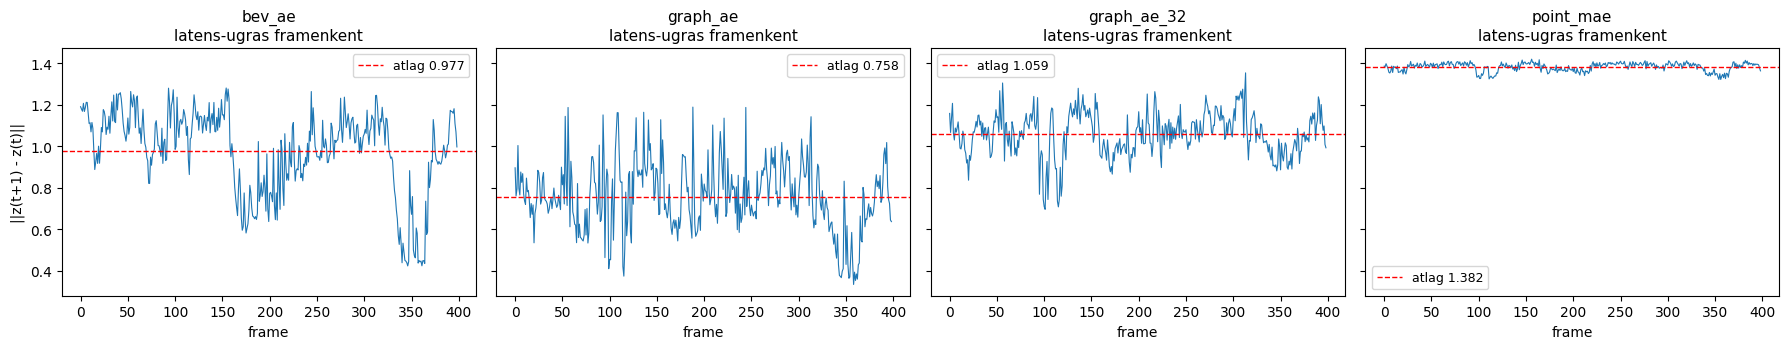

In [8]:
# Ahol TUSKE van, ott a latens atugrik: egy kanyar vagy elhalado auto
# megszakitja a folytonossagot. Az RL-nek ott szakad meg az allapot.
fig, axes = plt.subplots(1, len(LABELS), figsize=(4.5 * len(LABELS), 3.6),
                         sharey=True)
for ax, lbl in zip(axes, LABELS):
    d = (SM_LAT[lbl][1:] - SM_LAT[lbl][:-1]).norm(dim=1).numpy()
    ax.plot(d, lw=0.8)
    ax.axhline(d.mean(), color="red", ls="--", lw=1,
               label=f"atlag {d.mean():.3f}")
    ax.set_title(f"{lbl}\nlatens-ugras framenkent", fontsize=11)
    ax.set_xlabel("frame")
    ax.legend(fontsize=9)
axes[0].set_ylabel("||z(t+1) - z(t)||")
plt.tight_layout()
plt.show()


## 6. Linear probing - a donto meres

Az eddigi meresek **kozvetettek** voltak. Egyik sem arrol szol, amire az RL
hasznalja a latenst.

Ez a szakasz a self-supervised irodalom bevett mercejet futtatja: egyetlen
`nn.Linear` probalja kiolvasni a latensbol a fizikai informaciot. Ha ehhez
nemlinearitas kellene, az informacio nincs hasznalhato formaban.

RL-re ezt [Light-weight probing for RL (RLC 2024)](https://rlj.cs.umass.edu/2024/papers/RLJ_RLC_2024_242.pdf)
validalta: a linearis proba **korrelal a downstream RL teljesitmennyel**, 600x
kisebb koltseggel.

### Ket celfeladat

**1. BEV occupancy** - hol van akadaly felulnezetbol. **ELFOGULT**: a `bev_ae`
dekodere pontosan ezt rekonstrualja. Ha itt nyer, az nem erv.

**2. Szabad tavolsag szektoronkent** - 16 iranyban meddig lehet elmenni
utkozesig. Ezt **egyik modell sem latta** tanitas kozben, es kozvetlenul ez az,
amit egy vezeto agensnek tudnia kell. **Ez a valodi merce.**

### Ket dolgot ki kell egyenliteni

Kulonben nem a latenst merjuk, hanem az architektura meretet:

- **terbeli felbontas** - minden jellemzoterkep ugyanarra a racsra poolozva,
  a `point_mae` tokenjei a patch-kozeppontjuk szerint szorva
- **dimenzio** - PCA-val mind ugyanannyira


In [9]:
POOL = 8                      # minden jellemzoterkep ennyiszer ennyire
N_SECT = 16                   # szabad tavolsag ennyi szektorban
PROBE_DIM = 256               # PCA-val mind ennyire


@torch.no_grad()
def targets_from_points(pts, grid=32, n_sect=N_SECT, r_max=50.0):
    """Ket celertek framenkent.

    occ  : (grid*grid,) BEV occupancy, 32x32-re durvitva. A 128x128 tul sok
           cimke egy linearis regressziohoz; a durvitas zajt is szur.
    free : (n_sect,) szektoronkent a legkozelebbi pont tavolsaga - meddig
           lehet elmenni utkozesig. EZT egyik modell sem latta.
    """
    p = pts.to(DEVICE)
    x, y, z = p[:, 0], p[:, 1], p[:, 2]

    gx = ((x + r_max) / (2 * r_max) * grid).long().clamp(0, grid - 1)
    gy = ((y + r_max) / (2 * r_max) * grid).long().clamp(0, grid - 1)
    occ = torch.zeros(grid * grid, device=DEVICE)
    occ.scatter_reduce_(0, gy * grid + gx, torch.ones_like(x), reduce="amax")

    # Csak a VEZETES szempontjabol relevans magassag: a talaj (z < -1.5) es a
    # lombkorona (z > 2) nem akadaly.
    m = (z > -1.5) & (z < 2.0)
    ang = torch.atan2(y[m], x[m])
    rad = torch.sqrt(x[m] ** 2 + y[m] ** 2)
    sect = ((ang + np.pi) / (2 * np.pi) * n_sect).long().clamp(0, n_sect - 1)
    free = torch.full((n_sect,), r_max, device=DEVICE)
    free.scatter_reduce_(0, sect, rad, reduce="amin")
    return occ.cpu(), (free / r_max).cpu()


Y_OCC, Y_FREE = [], []
for i in tqdm(range(N_LAT), desc="celertekek", leave=False):
    o, f = targets_from_points(lat_pts[i])
    Y_OCC.append(o)
    Y_FREE.append(f)
Y_OCC, Y_FREE = torch.stack(Y_OCC), torch.stack(Y_FREE)

print(f"occupancy {tuple(Y_OCC.shape)}   foglalt cellak atlaga {Y_OCC.mean():.3f}")
print(f"szabad tav {tuple(Y_FREE.shape)}   atlag {Y_FREE.mean() * 50:.1f} m")


celertekek:   0%|          | 0/2000 [00:00<?, ?it/s]

occupancy (2000, 1024)   foglalt cellak atlaga 0.436
szabad tav (2000, 16)   atlag 14.1 m


In [10]:
@torch.no_grad()
def pooled_features(lbl):
    """A terbeli jellemzoterkep POOLxPOOL racsra hozva, majd PCA-val
    PROBE_DIM dimenziora. Igy sem a cellaszam, sem a csatornaszam nem ad
    elonyt - csak az INFORMACIO szamit."""
    z = LAT_SP[lbl]

    if z.ndim == 4:                               # (N, C, H, W)
        f = F.adaptive_avg_pool2d(z, POOL)
    else:                                         # (N, G, C) - point_mae
        # A tokeneket a PATCH-KOZEPPONTJUK szerint szorjuk a racsra, kulonben
        # a token-sorrend (FPS) hatarozna meg a helyuket, ami ertelmetlen.
        model, _ = load_model("point_mae")
        f = []
        for i in tqdm(range(0, N_LAT, 16), desc="point_mae racs", leave=False):
            _, c = model.encode(lat_pts[i:i + 16].to(DEVICE),
                                return_centers=True)
            c = model.denorm_centers(c)           # vissza meterbe
            gx = ((c[..., 0] + 50) / 100 * POOL).long().clamp(0, POOL - 1)
            gy = ((c[..., 1] + 50) / 100 * POOL).long().clamp(0, POOL - 1)
            cell = gy * POOL + gx

            tok = z[i:i + 16].to(DEVICE)
            B, G, Ch = tok.shape
            acc = torch.zeros(B, POOL * POOL, Ch, device=DEVICE)
            cnt = torch.zeros(B, POOL * POOL, 1, device=DEVICE)
            acc.scatter_reduce_(1, cell.unsqueeze(-1).expand(-1, -1, Ch), tok,
                                reduce="sum")
            cnt.scatter_reduce_(1, cell.unsqueeze(-1),
                                torch.ones(B, G, 1, device=DEVICE), reduce="sum")
            f.append((acc / cnt.clamp(min=1)).cpu())
            del tok, acc, cnt
        free_vram(model)
        f = torch.cat(f)

    f = f.reshape(N_LAT, -1)
    f = f - f.mean(0, keepdim=True)
    _, _, V = torch.pca_lowrank(f.double(), q=min(PROBE_DIM, min(f.shape)))
    return (f.double() @ V).float()


FEAT = {lbl: pooled_features(lbl) for lbl in LABELS}
for lbl, f in FEAT.items():
    print(f"{lbl:14s} {tuple(f.shape)}")


point_mae racs:   0%|          | 0/125 [00:00<?, ?it/s]

bev_ae         (2000, 256)
graph_ae       (2000, 256)
graph_ae_32    (2000, 256)
point_mae      (2000, 256)


In [11]:
# EGYETLEN nn.Linear, semmi tobb. A vagas 70/30, a framek veletlenszeruen
# lettek valasztva (LAT_IDX szort), tehat a teszt nem egy kulon utszakasz.
N_TR = int(0.7 * N_LAT)
perm = torch.randperm(N_LAT, generator=torch.Generator().manual_seed(0))
tr, te = perm[:N_TR], perm[N_TR:]


def iou_per_frame(pred, target):
    """FRAMENKENTI IoU, majd atlag - nem a teljes halmaz egyetlen unioja."""
    inter = (pred * target).sum(1)
    union = pred.sum(1) + target.sum(1) - inter
    return float((inter / union.clamp(min=1e-6)).mean())


def probe(X, Y, task, epochs=300, lr=1e-2, wd=1e-4):
    Xtr, Xte = X[tr].to(DEVICE), X[te].to(DEVICE)
    Ytr, Yte = Y[tr].to(DEVICE), Y[te].to(DEVICE)
    Xtr = (Xtr - (mu := Xtr.mean(0))) / (sd := Xtr.std(0) + 1e-6)
    Xte = (Xte - mu) / sd

    lin = nn.Linear(X.shape[1], Y.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(lin.parameters(), lr=lr, weight_decay=wd)
    lossf = nn.BCEWithLogitsLoss() if task == "occ" else nn.MSELoss()

    for _ in range(epochs):
        opt.zero_grad()
        lossf(lin(Xtr), Ytr).backward()
        opt.step()

    with torch.no_grad():
        pred = lin(Xte)
        if task == "occ":
            return iou_per_frame((pred.sigmoid() > 0.5).float(), Yte)
        # R^2 a KONSTANS joslathoz kepest. A konstans a TRAIN atlaga - a teszt
        # sajat atlagat hasznalni szivargas lenne.
        ss_res = ((pred - Yte) ** 2).sum()
        ss_tot = ((Yte - Ytr.mean(0)) ** 2).sum()
        return float(1 - ss_res / ss_tot)


PROBE_RES = {}
print(f"{'modell':14s} {'BEV IoU':>9s} {'szabad tav R2':>14s}")
print("-" * 40)
for lbl in LABELS:
    PROBE_RES[lbl] = (probe(FEAT[lbl], Y_OCC, "occ"),
                      probe(FEAT[lbl], Y_FREE, "free"))
    print(f"{lbl:14s} {PROBE_RES[lbl][0]:9.3f} {PROBE_RES[lbl][1]:14.3f}")

# Baseline: a konstans joslat. Aki ez ALATT van, az TULILLESZT.
const = (Y_OCC[tr].mean(0) > 0.5).float().expand(len(te), -1)
print(f"{'konstans':14s} {iou_per_frame(const, Y_OCC[te]):9.3f} "
      f"{0.0:14.3f}   <- baseline")

print("""
  BEV IoU       : ELFOGULT - a bev_ae dekodere pont ezt rekonstrualja.
  szabad tav R2 : a VALODI merce - ezt egyik modell sem latta tanitaskor.""")


modell           BEV IoU  szabad tav R2
----------------------------------------
bev_ae             0.793          0.554
graph_ae           0.684          0.639
graph_ae_32        0.634          0.526
point_mae          0.678          0.466
konstans           0.537          0.000   <- baseline

  BEV IoU       : ELFOGULT - a bev_ae dekodere pont ezt rekonstrualja.
  szabad tav R2 : a VALODI merce - ezt egyik modell sem latta tanitaskor.


## 7. Osszesites

In [12]:
# A SULY azt jeleli, mennyire szamit az RL-nek:
#   ***  kozvetlenul az RL-re vonatkozik
#   **   a latens hasznalhatosagat meri
#   *    szuro: alacsony ertek rossz, de a magas meg nem jo
ROWS = [
    ("RankMe cellankent",  "*",   lambda l: RANK_RES[l]["cell_ratio"], "{:.3f}"),
    ("k-NN konzisztencia", "**",  lambda l: KNN_RES[l][2],             "{:.2f}x"),
    ("idobeli simasag",    "**",  lambda l: SMOOTH_RES[l][2],          "{:.2f}x"),
    ("BEV IoU (elfogult)", "",    lambda l: PROBE_RES[l][0],           "{:.3f}"),
    ("szabad tav R2",      "***", lambda l: PROBE_RES[l][1],           "{:.3f}"),
]

print(f"{'meres':22s} {'suly':>5s} " + "".join(f"{l:>15s}" for l in LABELS))
print("-" * (28 + 15 * len(LABELS)))
for name, w, fn, fmt in ROWS:
    vals = {l: fn(l) for l in LABELS}
    best = max(vals, key=vals.get)
    cells = "".join(
        f"{(fmt.format(vals[l]) + (' *' if l == best else '  ')):>15s}"
        for l in LABELS)
    print(f"{name:22s} {w:>5s} {cells}")

print("\n  * = az adott meresen a legjobb")
print(f"\n  DONTES a *** soron: {max(LABELS, key=lambda l: PROBE_RES[l][1])}")

# --- A 16 vs 32 csatorna kerdese ------------------------------------------
# A cellankenti RankMe ABSZOLUT erteke a lenyeg: ha a 32-es aranyosan tobbet
# hasznal, a 16 szuk volt. Ha ugyanott marad, a plusz csatornak uresen allnak.
a, b = "graph_ae", "graph_ae_32"
print(f"\n  graph_ae 16 -> 32 csatorna:")
print(f"    cellankenti RankMe  {RANK_RES[a]['cell']:.1f} -> {RANK_RES[b]['cell']:.1f}"
      f"   (arany {RANK_RES[a]['cell_ratio']:.3f} -> {RANK_RES[b]['cell_ratio']:.3f})")
print(f"    szabad tav R2       {PROBE_RES[a][1]:.3f} -> {PROBE_RES[b][1]:.3f}"
      f"   ({100 * (PROBE_RES[b][1] / PROBE_RES[a][1] - 1):+.1f}%)")
print(f"    idobeli simasag     {SMOOTH_RES[a][2]:.2f}x -> {SMOOTH_RES[b][2]:.2f}x")


meres                   suly          bev_ae       graph_ae    graph_ae_32      point_mae
----------------------------------------------------------------------------------------
RankMe cellankent          *         0.725 *        0.504          0.481          0.576  
k-NN konzisztencia        **         1.51x *        1.51x          1.42x          1.39x  
idobeli simasag           **         1.44x          1.86x *        1.33x          1.03x  
BEV IoU (elfogult)                   0.793 *        0.684          0.634          0.678  
szabad tav R2            ***         0.554          0.639 *        0.526          0.466  

  * = az adott meresen a legjobb

  DONTES a *** soron: graph_ae

  graph_ae 16 -> 32 csatorna:
    cellankenti RankMe  8.1 -> 15.4   (arany 0.504 -> 0.481)
    szabad tav R2       0.639 -> 0.526   (-17.7%)
    idobeli simasag     1.86x -> 1.33x
